## Goal

Parse Azuki NFT Trades and do network analysis

## Imports

In [107]:
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

## Laod HTML

Downloaded from this site

In [35]:
fn = "../data/azuki_feb_19_2.html"

with open(fn) as fp:
    html = fp.read()
    
soup = BeautifulSoup(html)

## Parse

In [50]:
sales_div = soup.findAll('div', {'class': 'sales-ranking__summary-table-wrapper'})[2]
sales_table = sales_div.find('table', {'class': 'sales-ranking-table'})
# header = sales_table.find('thead')
rows = sales_table.findAll('tr')

In [101]:
transactions = {}

for row in rows[1:]:
    items = row.findAll('td')
    rank = int(items[0].text)
    desc = items[2].text.replace('\n', '')
    meta_data = items[2].text.split('\n')
    azuki_id = meta_data[3]
    a, b = items[7].text.split('\n\n\n\n')
    sender_addr = a.replace('\n', '')
    receiver_addr = b.replace('\n', '')
    res = items[3].text.split('\n\n\n\n')
    price_dollar = res[1].replace(',', '')
    price_ether = res[2]
    sold_days_ago = res[3].split('\n')[1]
    data = {"sendr": sender_addr, "recvr": receiver_addr, "price": price_dollar, 
            "ether": price_ether, "days_ago": sold_days_ago}
    transactions[azuki_id] = data


## Review Transactions raw data

In [104]:
len(transactions)

49

## Generate graph

In [108]:
g = nx.Graph()

In [109]:
for azuki_id, trans in transactions.items():
    sendr, rcvr = trans["sendr"], trans["recvr"]
    g.add_edge(sendr, rcvr)

## Draw graph

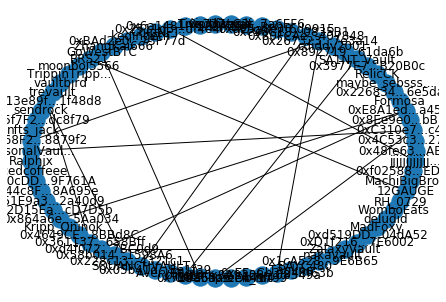

In [111]:
# nx.draw(g)
# plt.savefig("filename.png")

# drawing in circular layout
nx.draw_circular(g, with_labels = True)
plt.savefig("filename1.png")

//anaconda/envs/uatu/lib/python3.7/site-packages/networkx/drawing/layout.py:923: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  pos = np.row_stack((pos[x] for x in node_list))


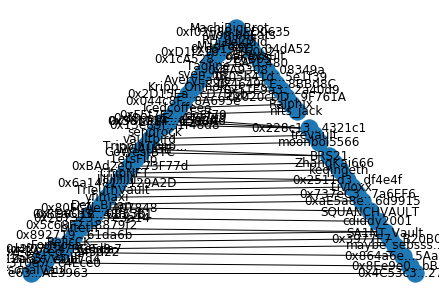

In [112]:
#clearing the current plot
plt.clf()
 
# drawing in planar layout
nx.draw_planar(g, with_labels = True)
plt.savefig("filename2.png")

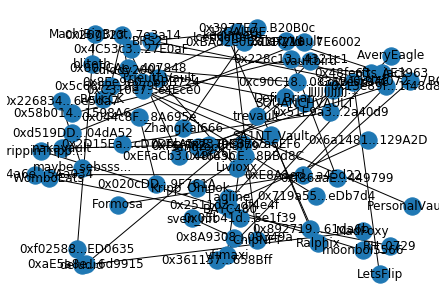

In [113]:
# clearing the current plot
plt.clf()
 
# drawing in random layout
nx.draw_random(g, with_labels = True)
plt.savefig("filename3.png")

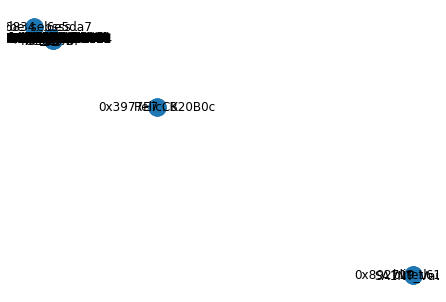

In [114]:
# clearing the current plot
plt.clf()
 
# drawing in spectral layout
nx.draw_spectral(g, with_labels = True)
plt.savefig("filename4.png")

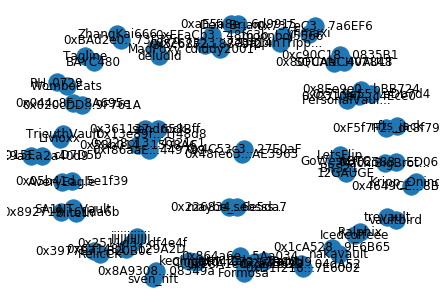

In [115]:
# clearing the current plot
plt.clf()
 
# drawing in spring layout
nx.draw_spring(g, with_labels = True)
plt.savefig("filename5.png")

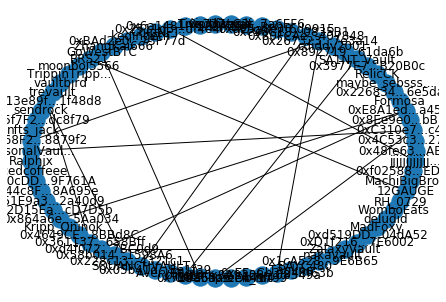

In [117]:
# clearing the current plot
plt.clf()
 
# drawing in shell layout
nx.draw_shell(g, with_labels = True)
plt.savefig("filename6.png")
